In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv(r"C:\Users\karth\Downloads\modified_placement_data.csv")

In [4]:
df.shape

(100, 3)

In [5]:
df['cgpa']=df['cgpa'].str.replace(',','.').astype(float)

In [6]:
df.head(10)

,cgpa,iq,placement
0,6.8,123.0,Yes
1,5.9,106.0,No
2,5.3,121.0,No
3,7.4,132.0,Yes
4,5.8,142.0,No
5,7.1,48.0,Yes
6,5.7,143.0,No
7,5.0,63.0,No
8,6.1,156.0,No
9,NaN,66.0,No


Steps 

1. extract input and output columns 
2. Scale the values 
3. train test split 
4. train the model 
5. evaluate the model/model selection
6. deploy the model


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       95 non-null     float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    object 
dtypes: float64(2), object(1)
memory usage: 2.5+ KB


In [10]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,Yes
1,5.9,106.0,No
2,5.3,121.0,No
3,7.4,132.0,Yes
4,5.8,142.0,No


In [11]:
df['placement']=df['placement'].replace({"Yes":"1","No":"0"})

In [12]:
df['placement']=df['placement'].astype(int)

In [40]:
df.fillna(method='ffill')

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


In [51]:
df[df['cgpa'].isna()].ffill()

,cgpa,iq,placement
9,NaN,66.0,0
54,NaN,141.0,1
81,NaN,107.0,0
85,NaN,166.0,1
91,NaN,158.0,1


In [56]:
df.ffill(inplace=True)

In [57]:
df['cgpa'].isna().value_counts()

False    100
Name: cgpa, dtype: int64

In [58]:
df.describe()

,cgpa,iq,placement
count,100.000000,100.000000,100.000000
mean,6.012000,123.580000,0.500000
std,1.164047,39.944198,0.502519
min,3.300000,37.000000,0.000000
25%,5.000000,101.500000,0.000000
50%,6.050000,127.500000,0.500000
75%,6.900000,149.000000,1.000000
max,8.500000,233.000000,1.000000


In [59]:
import matplotlib.pyplot as plt

In [60]:
df.columns

Index(['cgpa', 'iq', 'placement'], dtype='object')

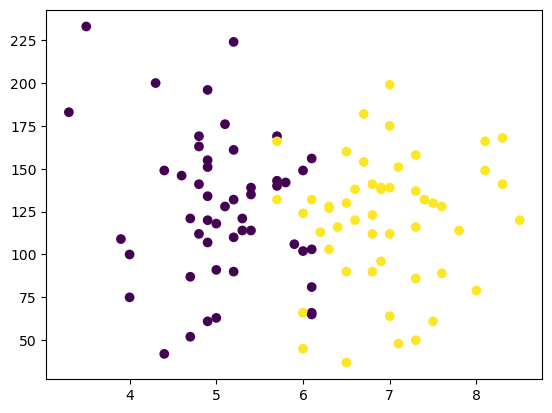

In [61]:
plt.scatter(x= df['cgpa'],y=df['iq'],c=df['placement'])

In [62]:
train_df = df.iloc[:,:2]
test_df = df.iloc[:,-1]

In [63]:
train_df.head()

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0


In [64]:
test_df.head()

0    1
1    0
2    0
3    1
4    0
Name: placement, dtype: int32

In [65]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(train_df,test_df,test_size=0.1)

In [66]:
X_train

,cgpa,iq
39,4.6,146.0
38,6.5,160.0
68,4.0,75.0
92,5.2,110.0
93,6.8,112.0
...,...,...
15,5.1,176.0
6,5.7,143.0
41,5.4,114.0
86,5.1,128.0


In [67]:
y_train

39    0
38    1
68    0
92    0
93    1
     ..
15    0
6     0
41    0
86    0
52    1
Name: placement, Length: 90, dtype: int32

In [68]:
X_test

,cgpa,iq
57,6.5,130.0
37,8.1,149.0
33,6.0,149.0
44,7.5,61.0
12,5.4,139.0
27,6.0,124.0
0,6.8,123.0
31,3.9,109.0
61,7.3,137.0
48,6.6,138.0


In [69]:
y_test

57    1
37    1
33    0
44    1
12    0
27    1
0     1
31    0
61    1
48    1
Name: placement, dtype: int32

In [70]:
#Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [71]:
X_train = scaler.fit_transform(X_train)

In [72]:
X_train

array([[-1.18603081,  0.55207086],
       [ 0.46150183,  0.89288874],
       [-1.70630428, -1.17636265],
       [-0.66575734, -0.32431796],
       [ 0.72163857, -0.27562969],
       [-0.66575734,  2.45091331],
       [ 1.41533653, -0.83554478],
       [ 0.72163857, -0.81120064],
       [-1.70630428, -0.5677593 ],
       [ 2.02232224,  0.43035019],
       [-1.09931857, -0.05653249],
       [-0.14548388,  0.45469433],
       [ 0.2013651 , -0.25128556],
       [ 0.46150183, -0.81120064],
       [ 0.89506306,  0.38166192],
       [ 0.63492632,  1.42845968],
       [-1.01260632,  0.96592114],
       [-2.1398655 ,  2.67001052],
       [-0.66575734, -0.81120064],
       [-1.09931857, -0.88423304],
       [-1.44616755,  1.8666541 ],
       [ 2.02232224,  1.08764181],
       [-0.5790451 , -0.22694143],
       [ 0.11465286, -0.4947269 ],
       [-0.83918183, -0.12956489],
       [ 0.63492632,  0.74682393],
       [-0.23219612,  0.21125299],
       [ 0.11465286, -1.39545986],
       [-0.92589408,

In [73]:
X_test = scaler.transform(X_test)

In [74]:
X_test

array([[ 0.46150183,  0.16256472],
       [ 1.84889775,  0.62510326],
       [ 0.02794061,  0.62510326],
       [ 1.32862428, -1.51718053],
       [-0.49233286,  0.38166192],
       [ 0.02794061,  0.01649991],
       [ 0.72163857, -0.00784422],
       [-1.79301652, -0.3486621 ],
       [ 1.15519979,  0.33297366],
       [ 0.54821408,  0.35731779]])

In [75]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

In [76]:
#Model Training
clf.fit(X_train,y_train)

LogisticRegression()

In [79]:
y_pred = clf.predict(X_test)

In [82]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,y_pred)

0.9

<Axes: >

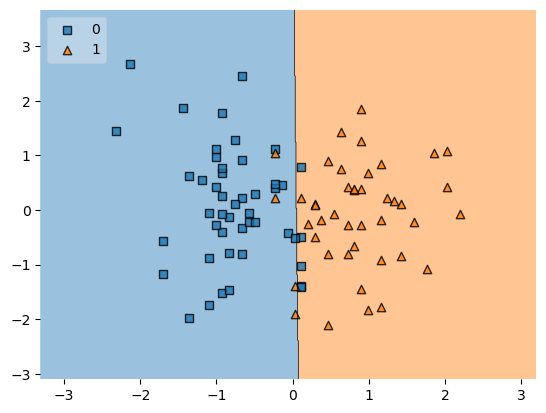

In [85]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X_train,y_train.values,clf=clf,legend = 2)

##### Our model is splitting the data like above graph that line is the decision boundary and it is making some mistake that is why the model accuracy is 90%

In [86]:
import pickle 

In [87]:
pickle.dump(clf,open("model.pkl",'wb'))